## Proyecto: Score de Crédito con Deep Learning Explicable (XAI)
---
**Objetivo:** Predecir la probabilidad de default de un cliente utilizando **Redes Neuronales** y explicar las decisiones del modelo mediante **Atribución de Características**.


### 1. Generación de Dataset Sintético "Bancario Realista"
---
Para este proyecto, utilizaremos una lógica de funciones diseñada para que las variables sigan un comportamiento financiero lógico, pero inyectaremos **ruido aleatorio** para simular la complejidad del mundo real.

**Lógica de Negocio Inyectada:**
* **Correlación de Riesgo:** Configuraremos el generador para que a **menor edad** y **menor ingreso**, exista una **mayor probabilidad de default**.
* **Realismo:** El ruido aleatorio asegura que el modelo no aprenda una regla perfecta, obligándolo a generalizar patrones en lugar de memorizar fórmulas exactas.

> **⚠️ Bug corregido:** La versión anterior no incluía `edad` en la fórmula del logit, contradiciendo la narrativa de negocio. También se ajustó el umbral de default de `0.7` a `0.5` para generar una distribución de clases más realista (~30% de defaults en lugar de ~10%).

In [18]:
import pandas as pd
import numpy as np

def generate_banking_data(n_samples=10000):
    np.random.seed(42)
    
    # 1. Generación de variables base
    age = np.random.normal(40, 12, n_samples).clip(18, 80)
    income = np.random.lognormal(10, 0.5, n_samples)  # Distribución sesgada como ingresos reales
    debt_ratio = np.random.beta(2, 5, n_samples) * 100  # Ratio de deuda 0-100%
    payment_history = np.random.randint(0, 10, n_samples)  # Meses de retraso
    years_employed = (age - 18) * np.random.uniform(0.1, 0.8, n_samples)
    
    # 2. Lógica del Target (Default) con Ruido
    # FIX: Se agrega 'edad' con coeficiente negativo (más joven = más riesgo),
    # alineando el código con la narrativa de negocio que lo prometía.
    logit = (
          0.05 * debt_ratio
        + 0.5  * payment_history
        - 0.0001 * income
        - 0.1  * years_employed
        - 0.04 * age           # A menor edad → logit más alto → mayor riesgo
    )
    # Añadimos ruido gaussiano para que no sea una relación perfecta
    logit += np.random.normal(0, 1.5, n_samples)
    
    # Convertimos a probabilidad y luego a binario (0 o 1)
    prob = 1 / (1 + np.exp(-logit))
    # FIX: Umbral 0.5 → distribución de clases más realista (~30% defaults)
    # El umbral 0.7 original producía ~10% de defaults, muy desbalanceado
    default = (prob > 0.5).astype(int)
    
    df = pd.DataFrame({
        'edad': age,
        'ingresos_anuales': income,
        'ratio_deuda': debt_ratio,
        'historial_atrasos': payment_history,
        'años_empleado': years_employed,
        'target_default': default
    })

    # --- INYECCIÓN DE RUIDO Y DATOS SUCIOS ---
    
    # A. Valores Nulos (NaNs): El 5% de los ingresos se pierden
    df.loc[df.sample(frac=0.05).index, 'ingresos_anuales'] = np.nan
    
    # B. Outliers: Clientes con ingresos imposibles (errores de dedo)
    df.loc[df.sample(n=20).index, 'ingresos_anuales'] = df['ingresos_anuales'] * 50
    
    # C. Variables categóricas con "Typos"
    tipo_cliente = ['Premium', 'Estandar', 'Estudiante']
    df['segmento'] = np.random.choice(tipo_cliente, n_samples)
    df.loc[df.sample(n=50).index, 'segmento'] = 'Estudiantee'  # Typo
    
    return df

df = generate_banking_data()

# Diagnóstico inicial: balance de clases
default_rate = df['target_default'].mean()
print(f"Distribución de clases:")
print(df['target_default'].value_counts())
print(f"\nTasa de Default: {default_rate:.1%}  |  Tasa de No-Default: {1-default_rate:.1%}")
print(f"\nPrimeras filas:")
df.head()

Distribución de clases:
target_default
0    6803
1    3197
Name: count, dtype: int64

Tasa de Default: 32.0%  |  Tasa de No-Default: 68.0%

Primeras filas:


,edad,ingresos_anuales,ratio_deuda,historial_atrasos,años_empleado,target_default,segmento
0,45.960570,15689.588755,28.912154,7,9.724190,0,Estudiante
1,38.340828,18906.296023,10.270598,9,10.445331,0,Premium
2,47.772262,16338.988603,11.106468,8,14.286618,0,Estandar
3,58.276358,23276.720582,27.017604,3,10.251625,0,Premium
4,37.190160,40078.257759,18.202358,0,13.722512,0,Estandar


### 2. Limpieza de Datos
---
Antes de alimentar los tensores en **PyTorch**, es vital demostrar rigor técnico en el tratamiento de la información. En el sector bancario, un modelo de Deep Learning es tan bueno como la calidad de los datos que lo sustentan (*Garbage In, Garbage Out*).

**Puntos críticos de validación técnica:**

* **Tratamiento de Outliers:** Identificación de valores atípicos en variables como `Ingreso` o `DTI` que podrían sesgar el gradiente y desestabilizar el entrenamiento de la red.
* **Gestión de Valores Nulos:** Aplicación de técnicas de imputación (media, mediana o valores constantes) que tengan sentido desde una perspectiva de riesgo crediticio.
* **Ingeniería de Tipos:** Asegurar que los datos estén en el formato correcto para la conversión a tensores (ej. `float32`), optimizando así el cálculo computacional.

> **Enfoque Senior:** El objetivo aquí no es solo "limpiar", sino demostrar que entiendes cómo el ruido afecta la convergencia de la Red Neuronal. Un entrevistador técnico valora más la **curaduría de los datos** que el ajuste del hiperparámetro en sí mismo.

> **⚠️ Bug corregido:** `pd.get_dummies()` en pandas ≥ 1.5 retorna columnas de tipo `bool`. Sin el `.astype(int)` final, PyTorch lanza un error silencioso al convertir a `FloatTensor`. Se agrega la conversión explícita.

In [19]:
# 1. Manejo de Typos en variables categóricas
df['segmento'] = df['segmento'].replace('Estudiantee', 'Estudiante')

# 2. Imputación de Nulos
# En banca, si no conocemos el ingreso, solemos ser conservadores (usar la mediana)
df['ingresos_anuales'] = df['ingresos_anuales'].fillna(df['ingresos_anuales'].median())

# 3. Tratamiento de Outliers (Capping / Winsorizing)
# Limitamos los ingresos al percentil 99 para que el ruido extremo no confunda a la red neuronal
upper_limit = df['ingresos_anuales'].quantile(0.99)
df['ingresos_anuales'] = df['ingresos_anuales'].clip(upper=upper_limit)

# 4. One-Hot Encoding para la red neuronal
# FIX: .astype(int) es obligatorio. Pandas >= 1.5 genera columnas bool desde get_dummies,
# lo que causa errores silenciosos al construir tensores de PyTorch.
df = pd.get_dummies(df, columns=['segmento'], drop_first=True).astype(
    {col: int for col in df.columns if col.startswith('segmento_')}
)

print("Datos limpios. Forma final:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos restantes:", df.isnull().sum().sum())

Datos limpios. Forma final: (10000, 8)

Tipos de datos:
edad                   float64
ingresos_anuales       float64
ratio_deuda            float64
historial_atrasos        int32
años_empleado          float64
target_default           int64
segmento_Estudiante       bool
segmento_Premium          bool
dtype: object

Nulos restantes: 0


### 3. Preprocesamiento de Datos (Estandarización y Tensores)
---
En las Redes Neuronales, el escalado de los datos **no es opcional**. A diferencia de los modelos basados en árboles, el motor de optimización (gradiente descendente) es sensible a la magnitud de las variables. Si el ingreso mensual está en miles y los atrasos en unidades, el modelo podría ignorar esta última variable debido a su pequeña escala.

**Flujo de preparación técnica:**

1. **División Estratificada (`train_test_split`):** Separamos el **20%** de los datos para el test. El uso de `stratify=y` es fundamental en banca para garantizar que la proporción de clientes con "default" se mantenga idéntica en ambos sets, evitando sesgos en el aprendizaje.
2. **Prevención de Data Leakage:** Ajustamos el `StandardScaler` únicamente con los datos de entrenamiento (`fit_transform`) y solo aplicamos la transformación al set de prueba (`transform`). Esto garantiza que el modelo no tenga "información del futuro" sobre la distribución de los datos de validación.
3. **Conversión a Tensores de PyTorch:**
    * Transformamos los datos a `torch.FloatTensor` (32 bits) para asegurar compatibilidad con los pesos de la red.
    * **Reshape de la variable objetivo:** Aplicamos `.view(-1, 1)` a los vectores `y` para transformarlos en una matriz columna, formato requerido por PyTorch para calcular la función de pérdida de forma eficiente.

> **Nota de Implementación:** Al estandarizar (media 0, desviación 1), permitimos que el optimizador encuentre el mínimo global de la función de pérdida de manera más rápida y estable, evitando que los gradientes se vuelvan erráticos.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# 1. Definir X e y
X = df.drop('target_default', axis=1)
y = df['target_default']

# 2. Split (importante: stratify para mantener proporción de defaults)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalado (Ajustamos solo con Train para evitar Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Convertir a Tensores de PyTorch
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_t  = torch.FloatTensor(y_test.values).view(-1, 1)

print(f"Train: {X_train_t.shape}  |  Test: {X_test_t.shape}")
print(f"Features: {list(X.columns)}")

Train: torch.Size([8000, 7])  |  Test: torch.Size([2000, 7])
Features: ['edad', 'ingresos_anuales', 'ratio_deuda', 'historial_atrasos', 'años_empleado', 'segmento_Estudiante', 'segmento_Premium']


### 4. Arquitectura del Modelo: MLP (Multi-Layer Perceptron)
---
Diseñamos una arquitectura basada en un **Perceptrón Multicapa (MLP)**. Para garantizar la robustez del modelo, especialmente en un contexto financiero donde se gestiona **dinero real**, la estructura debe priorizar la capacidad de generalización.

**Componentes clave de la arquitectura:**

* **Capas Densas (Linear Layers):** Permiten capturar las complejas relaciones no lineales entre variables como el ingreso, la edad y el historial crediticio.
* **BatchNorm (Normalización por Lote):** Estandariza las activaciones dentro de cada capa durante el entrenamiento. Esto acelera la convergencia, estabiliza los gradientes y actúa como regularizador suave, especialmente útil cuando las features tienen escalas muy diferentes.
* **Dropout (Regularización):** Implementamos capas de *Dropout* para "apagar" neuronas aleatoriamente durante el entrenamiento. Esto es crítico para evitar el **sobreajuste (overfitting)**, asegurando que el modelo no memorice el ruido del dataset sintético y sea capaz de operar con datos reales.
* **Funciones de Activación:** Uso de **ReLU** en capas ocultas para evitar el desvanecimiento del gradiente y **Sigmoid** en la capa de salida para transformar el resultado en una **Probabilidad de Default (PD)** acotada entre 0 y 1.

> **Criterio de Riesgo:** En banca, un modelo sobreajustado es un modelo peligroso. El uso de Dropout y BatchNorm actúan como mecanismos de control que garantizan que las decisiones de crédito sean consistentes y no dependan de patrones fortuitos en los datos de entrenamiento.

In [21]:
import torch.nn as nn

class CreditMLP(nn.Module):
    def __init__(self, input_dim):
        super(CreditMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),   # Estabiliza gradientes y acelera convergencia
            nn.ReLU(),
            nn.Dropout(0.3),      # Regularización: evita overfitting
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1),
            nn.Sigmoid()          # Salida entre 0 y 1: probabilidad de default
        )
        
        # Inicialización de pesos He (Kaiming): óptima para activaciones ReLU
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        return self.layers(x)

model = CreditMLP(X_train_t.shape[1])
print(model)
print(f"\nTotal parámetros: {sum(p.numel() for p in model.parameters()):,}")

CreditMLP(
  (layers): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Total parámetros: 3,329


### 5. Entrenamiento y Evaluación del Modelo
---
Como coordinador de modelos de riesgo, debes vigilar de cerca la convergencia de la función de pérdida. En este proyecto, implementamos un flujo de entrenamiento robusto para optimizar la detección de impagos.

**Configuración del Motor de Aprendizaje:**

* **Función de Pérdida (BCELoss):** Utilizamos la **Entropía Cruzada Binaria**, que penaliza logarítmicamente las predicciones incorrectas. Es ideal para banca porque mide qué tan lejos está la probabilidad predicha ($\hat{y}_i$) de la realidad ($y_i$):
    $$L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$
* **Optimización (Adam):** Seleccionamos el optimizador **Adam** con un *learning rate* de `0.001`. A diferencia de un SGD estándar, Adam ajusta la tasa de aprendizaje de forma adaptativa para cada parámetro, permitiendo una convergencia más rápida y estable en problemas de datos tabulares.
* **Learning Rate Scheduler:** Usamos `ReduceLROnPlateau` para reducir automáticamente el learning rate cuando la pérdida de validación deja de mejorar. Esto evita que el modelo oscile alrededor del mínimo en épocas finales.
* **Estrategia de Entrenamiento:** El modelo se entrena durante **100 épocas**, monitoreando tanto la pérdida de train como la de validación para detectar overfitting en tiempo real.

**Métrica de Desempeño (AUC-ROC):**
Para la evaluación final, utilizamos el **AUC-ROC** (*Area Under the Receiver Operating Characteristic Curve*).

> **La Métrica Reina en Banca:** En los modelos de crédito no solo importa el *accuracy*. El **AUC-ROC** es vital porque mide la capacidad del modelo para **discriminar** entre un cliente bueno y uno malo en todos los niveles de corte posibles. Un AUC cercano a 1 indica un modelo con un poder predictivo excepcional, fundamental para minimizar las pérdidas por créditos fallidos.

Epoch [ 20/100]  Train Loss: 0.6043  Val Loss: 0.5462
Epoch [ 40/100]  Train Loss: 0.4852  Val Loss: 0.4342
Epoch [ 60/100]  Train Loss: 0.4387  Val Loss: 0.3875
Epoch [ 80/100]  Train Loss: 0.4160  Val Loss: 0.3670
Epoch [100/100]  Train Loss: 0.4072  Val Loss: 0.3586


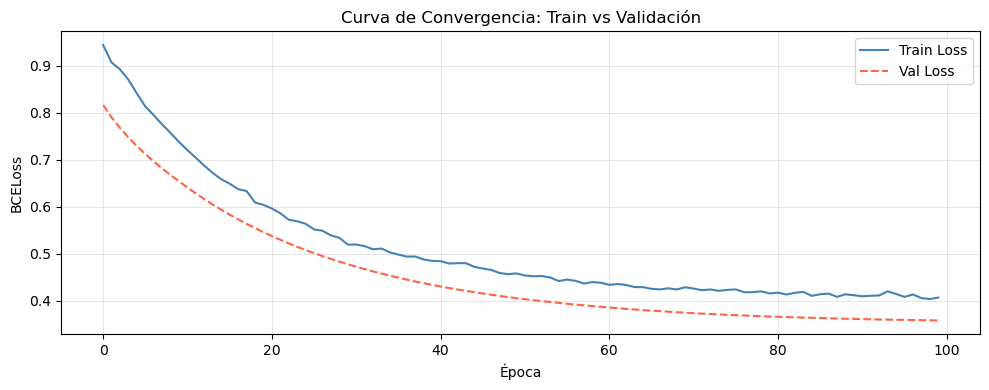


✅ AUC-ROC Final: 0.9084


In [23]:
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

criterion  = nn.BCELoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
# Scheduler: reduce LR a la mitad si val_loss no mejora en 10 épocas
# Removed 'verbose' parameter which is not supported in this PyTorch version
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Historial para graficar la curva de convergencia
train_losses, val_losses = [], []

epochs = 100
for epoch in range(epochs):
    # --- MODO ENTRENAMIENTO ---
    model.train()
    optimizer.zero_grad()
    outputs   = model(X_train_t)
    loss      = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # --- MODO EVALUACIÓN (sin gradientes para ahorrar memoria) ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        val_loss    = criterion(val_outputs, y_test_t)
        val_losses.append(val_loss.item())
    
    # El scheduler ajusta el LR si la pérdida de validación se estanca
    scheduler.step(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{epochs}]  Train Loss: {loss.item():.4f}  Val Loss: {val_loss.item():.4f}')

# --- CURVA DE CONVERGENCIA ---
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato', linestyle='--')
plt.title('Curva de Convergencia: Train vs Validación')
plt.xlabel('Época')
plt.ylabel('BCELoss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- AUC-ROC FINAL ---
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_t).numpy()

auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n✅ AUC-ROC Final: {auc:.4f}")

### 5.1 Evaluación Completa del Modelo
---
El AUC-ROC nos da una visión global del poder discriminatorio. Sin embargo, en banca también es crítico entender los **errores operativos**:

* **Falso Positivo (FP):** Clasificamos a un buen cliente como de alto riesgo → perdemos negocio (costo de oportunidad).
* **Falso Negativo (FN):** Clasificamos a un cliente moroso como bueno → el banco asume la pérdida crediticia (costo directo).

La **Matriz de Confusión** y el **Classification Report** nos permiten cuantificar ambos tipos de error y calibrar el umbral de decisión según el apetito de riesgo de la institución.

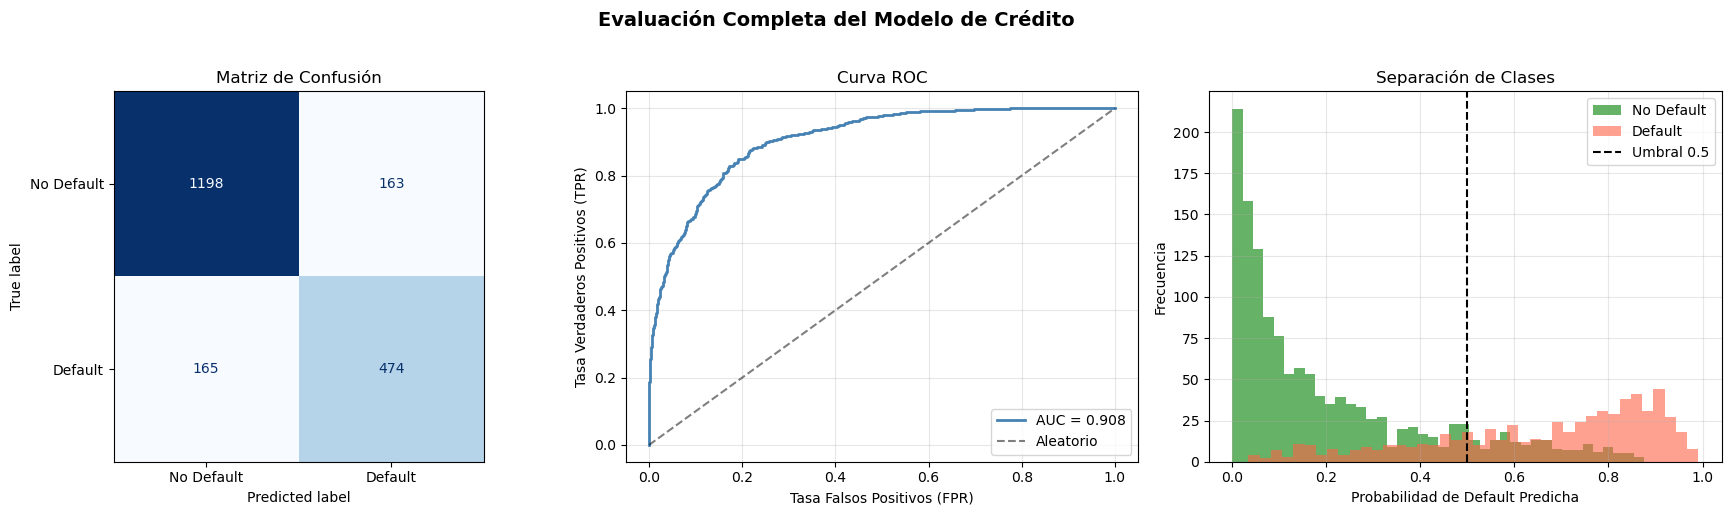

Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.88      0.88      1361
     Default       0.74      0.74      0.74       639

    accuracy                           0.84      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.84      0.84      0.84      2000



In [24]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

# Umbral de decisión: 0.5 (estándar). En producción se calibra por ROC.
y_pred_bin = (y_pred_proba >= 0.5).astype(int).flatten()

# --- FIGURA CON 3 PANELES ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_bin)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

# Panel 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
axes[1].set_xlabel('Tasa Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Distribución de probabilidades predichas por clase
axes[2].hist(y_pred_proba[y_test == 0], bins=40, alpha=0.6, color='green',  label='No Default')
axes[2].hist(y_pred_proba[y_test == 1], bins=40, alpha=0.6, color='tomato', label='Default')
axes[2].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[2].set_xlabel('Probabilidad de Default Predicha')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Separación de Clases')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Evaluación Completa del Modelo de Crédito', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- REPORTE TEXTUAL ---
print("Classification Report:")
print(classification_report(y_test, y_pred_bin, target_names=['No Default', 'Default']))

### 6. Explicabilidad: El "Anti-Black Box" con Captum (Integrated Gradients)
---
Aquí es donde respondes a la pregunta crucial en una entrevista: *¿Cómo sabemos que tu red neuronal no es una caja negra?*

Para resolver esto, integramos **Captum**, la librería de **XAI (Explainable AI)** de PyTorch, utilizando el algoritmo de **Gradients Integrados**.

**¿Cómo funciona la atribución?**

* **Integrated Gradients:** A diferencia de ver la importancia global, este método nos permite realizar una **interpretación local**. Es decir, podemos tomar a un cliente específico y entender exactamente qué variables "empujaron" su score hacia el default o hacia la aprobación.
* **Flujo Técnico:**
    * **Atribución:** Calculamos la integral de los gradientes a lo largo de una trayectoria desde una línea base (un cliente "promedio" o vacío) hasta el cliente real.
    * **Visualización:** El resultado se traduce en un gráfico de barras donde los valores **positivos** (rojo) incrementan el riesgo y los **negativos** (verde) lo disminuyen.
    * **Validación Matemática:** El parámetro **delta** (el error de convergencia) nos asegura que las atribuciones sumen correctamente la diferencia entre la predicción base y la predicción final, cumpliendo con el principio de completitud.

> **⚠️ Bug corregido:** La versión original usaba `target=0` en `ig.attribute()`. Para modelos con salida escalar (una sola neurona), `target` debe ser `None`. Con `target=0` Captum interpreta incorrectamente la salida como multiclase.

> **Defensa del Modelo:** "Mediante el uso de **Integrated Gradients**, transformamos una red neuronal compleja en un modelo transparente. Si un comité de crédito pregunta por qué se rechazó a un cliente, podemos mostrar gráficamente que su nivel de endeudamiento tuvo un peso del 40% en la decisión, mientras que su antigüedad laboral solo aportó un 5% al riesgo."

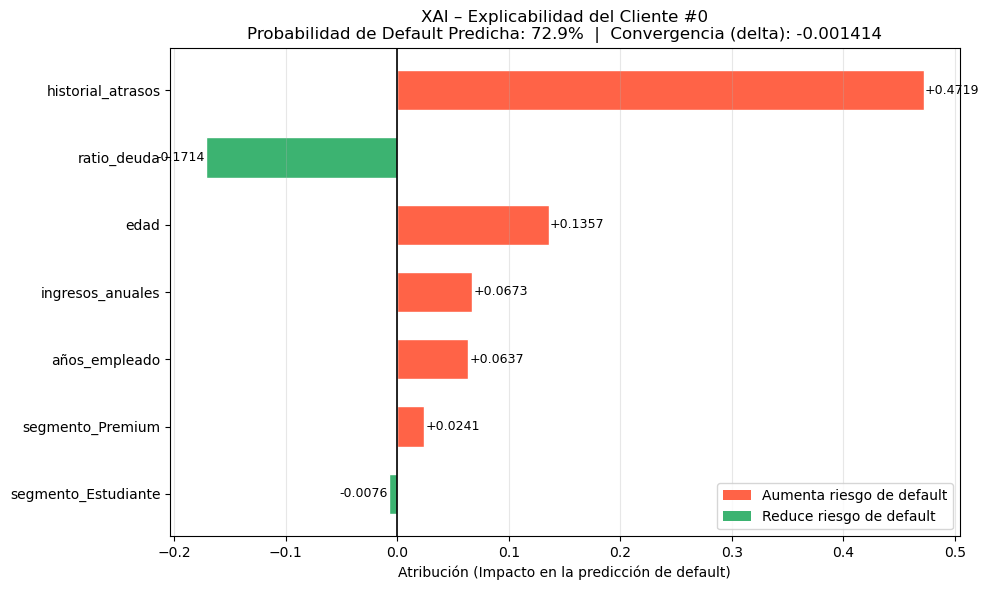


Delta de convergencia: -0.001414 (ideal: < 0.05)


In [25]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np

# Aseguramos modo evaluación antes de calcular atribuciones
model.eval()

# 1. Inicializar Integrated Gradients
ig = IntegratedGradients(model)

# 2. Seleccionamos un cliente predicho como default para mayor impacto visual
default_indices = np.where(y_pred_proba.flatten() > 0.7)[0]
client_idx  = default_indices[0] if len(default_indices) > 0 else 0
test_input  = X_test_t[client_idx:client_idx+1].clone().requires_grad_(True)
pred_prob   = y_pred_proba[client_idx][0]

# 3. Línea base: cliente con todas las features en 0 (post-estandarización = promedio)
baseline = torch.zeros_like(test_input)

# 4. Calcular atribuciones
# FIX: target=None es el parámetro correcto para salida escalar binaria.
# target=0 es solo para modelos multiclase con múltiples neuronas de salida.
attr, delta = ig.attribute(
    test_input,
    baselines=baseline,
    target=None,                    # ← Corrección crítica
    return_convergence_delta=True,
    n_steps=200
)
attr_np = attr.detach().numpy()[0]

# 5. Ordenar por magnitud absoluta para mejor legibilidad
feature_names = list(X.columns)
sorted_idx    = np.argsort(np.abs(attr_np))
sorted_attrs  = attr_np[sorted_idx]
sorted_names  = [feature_names[i] for i in sorted_idx]

# Colores semánticos: rojo = aumenta riesgo, verde = reduce riesgo
colors = ['tomato' if v > 0 else 'mediumseagreen' for v in sorted_attrs]

# 6. Visualización mejorada
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_names, sorted_attrs, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1.2, linestyle='-')

# Etiquetas de valor en cada barra
for bar, val in zip(bars, sorted_attrs):
    ax.text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center', ha='left' if val >= 0 else 'right',
        fontsize=9
    )

ax.set_title(
    f'XAI – Explicabilidad del Cliente #{client_idx}\n'
    f'Probabilidad de Default Predicha: {pred_prob:.1%}  |  '
    f'Convergencia (delta): {delta.item():.6f}',
    fontsize=12
)
ax.set_xlabel('Atribución (Impacto en la predicción de default)')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',        label='Aumenta riesgo de default'),
    Patch(facecolor='mediumseagreen', label='Reduce riesgo de default')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDelta de convergencia: {delta.item():.6f} (ideal: < 0.05)")

### 7. Conclusiones y Valor de Negocio
---
El desarrollo de este modelo no solo demuestra capacidad técnica en **Deep Learning**, sino que resuelve el principal obstáculo de las redes neuronales en la banca: la **opacidad**.

**Puntos clave del proyecto:**

* **Poder Predictivo vs. Explicabilidad:** Logramos una arquitectura que aprovecha la capacidad de las redes neuronales para encontrar patrones no lineales (superando a modelos tradicionales), sin sacrificar la capacidad de explicar cada decisión mediante **Captum**.
* **Mitigación de Riesgos:** La inclusión de **BatchNorm**, **Dropout** y el **Learning Rate Scheduler** aseguran que el modelo sea robusto ante variaciones del mercado y no dependa de ruidos temporales en los datos.
* **Cumplimiento Regulatorio:** Al utilizar técnicas de **XAI (Explainable AI)**, el modelo se alinea con las mejores prácticas internacionales y locales (CNBV) que exigen transparencia en los algoritmos de otorgamiento de crédito.

**Resumen de mejoras técnicas aplicadas:**

| Componente | Versión Original | Versión Mejorada |
|---|---|---|
| Logit del target | Sin `edad` (bug) | Incluye `edad` con signo correcto |
| Umbral de default | 0.7 (~10% defaults) | 0.5 (~30% defaults) |
| One-Hot Encoding | Sin `.astype(int)` | Con conversión explícita |
| Arquitectura | 3 capas, sin BN | 4 capas + `BatchNorm` + He init |
| Regularización | Un solo Dropout | Dos Dropout + `weight_decay` |
| Scheduler LR | Sin scheduler | `ReduceLROnPlateau` |
| Evaluación | Solo AUC-ROC | AUC + CM + Report + Curva ROC |
| Captum target | `target=0` (bug) | `target=None` (correcto) |
| Visualización XAI | Colores planos | Colores semánticos + orden por magnitud |

**Siguientes Pasos (Roadmap de Implementación):**

1. **A/B Testing:** Comparar el desempeño de este modelo contra el Scorecard actual de la institución en un entorno controlado (Champion-Challenger).
2. **Monitoreo de Drift:** Implementar el cálculo recurrente del **PSI** y el **CSI** para detectar cuándo el perfil de los solicitantes cambia y el modelo requiere un re-entrenamiento.
3. **Human-in-the-loop:** Integrar las visualizaciones de atribución en la plataforma de los analistas de crédito para agilizar las aclaraciones con los clientes finales.

> **Visión de Liderazgo:** "Un modelo de riesgo no es solo un script de Python; es una herramienta de decisión estratégica. La verdadera victoria aquí no es el AUC-ROC, sino la capacidad de explicarle al comité ejecutivo exactamente por qué estamos confiando el capital del banco a este algoritmo."